# **🏛️ Reto 01: Expected Credit Loss**

*Modelización de riesgo de crédito de una cartera de Lending Club — Reto mensual de octubre*

> **Objetivo:** estimar la pérdida esperada de la cartera como ECL = PD (Probability of Default) × LGD (Loss Given Default) × EAD (Exposure at Default),
> lo más precisa posible y con sesgo conservador: el ECL total estimado debe superar
> al real, y como máximo el 10% de los préstamos puede quedar por debajo de su ECL real.
> Todo el pipeline depende de una única variable `SEED` (CONFIG). 

## **📦 Semana 1 · Recepción de la cartera y cimientos anti-fuga**

### **1.1 ⚙️Setup y CONFIG: el panel de control del reto**

En esta primera celda preparamos el entorno de trabajo. Por un lado importamos las librerías que usaremos en todo el notebook: `numpy` y `pandas` para el manejo de datos, `matplotlib` y `seaborn` para los gráficos y `train_test_split` para partir la muestra. También silenciamos los avisos (`warnings`) para mantener el notebook limpio.

Por otro lado definimos el **CONFIG del proyecto**: un bloque con los seis parámetros que controlan todo (la semilla `SEED`, el identificador del dataset en Kaggle, los nombres de los dos ficheros, el nombre de la variable objetivo y el tamaño de la muestra de test). Las reglas del reto dicen que cuando se publique la semilla oficial solo podremos cambiar una variable: gracias a este CONFIG, esa variable vive aquí y en ningún otro sitio.

Por último fijamos la semilla con `np.random.seed(SEED)` para que cualquier operación aleatoria sea reproducible, y configuramos la estética: estilo de los gráficos y cómo pandas muestra las tablas (todas las columnas y decimales controlados).

In [ ]:
# --- Librerías generales del proyecto ---
import numpy as np                      # cálculo numérico y control de aleatoriedad
import pandas as pd                     # DataFrames y manipulación de datos
import matplotlib.pyplot as plt         # motor de gráficos
import seaborn as sns                   # gráficos estadísticos sobre matplotlib
from sklearn.model_selection import train_test_split   # partición train/test
import warnings
warnings.filterwarnings('ignore')       # silenciar avisos para un notebook limpio

# --- CONFIG: único panel de control del proyecto ---
SEED        = 42
DATASET_ID  = "db0boy/lending-club-loan-data-cleared"   # owner/slug en Kaggle
FILE_X      = "X.csv"                                   # fichero de features
FILE_TARGET = "target.csv"                              # fichero de target
TARGET_COL  = "y"                                       # variable objetivo (1 = impago)
TEST_SIZE   = 0.20                                      # proporción reservada para test

# --- Reproducibilidad y estética ---
np.random.seed(SEED)                                        # fija la aleatoriedad global de NumPy
sns.set_theme(style="whitegrid", palette="muted")           # estilo de todos los gráficos
pd.set_option('display.max_columns', None)                  # mostrar todas las columnas
pd.set_option('display.float_format', lambda x: '%.3f' % x) # floats a 3 decimales

print("✅ Librerías cargadas, semilla fijada y CONFIG definido.")

✅ Librerías cargadas, semilla fijada y CONFIG definido.


### **1.2 📥 Carga de datos desde Kaggle sin salir del notebook**

En lugar de descargar los CSV a mano, usamos `kagglehub`, la librería oficial de Kaggle. Funciona como un mensajero: busca las credenciales que dejamos guardadas en nuestro equipo (`~/.kaggle/access_token`), comprueba si el dataset ya está en la caché local y, si no, lo descarga y nos lo devuelve directamente como DataFrames de pandas.

Cargamos dos ficheros: `X.csv`, con las 45 variables explicativas, y `target.csv`, con la variable objetivo `Y` (1 = impago). Después los pegamos por columnas con `pd.concat` para tener la cartera completa en una única tabla de 46 columnas.

Cerramos con tres comprobaciones de "recepción del paquete": el número de préstamos y variables (2,139,643 × 46), la tasa de impago global (13.07%, que es simplemente la media de una columna de ceros y unos) y una vista de las primeras filas, los nombres de columna y los estadísticos básicos, que nos darán las primeras pistas de nulos y valores extremos.

In [ ]:
# ============================================================
# 📥 CARGA DE DATOS DESDE KAGGLE (vía kagglehub)
# ============================================================

# --- Imports específicos de la carga ---
# kagglehub descarga datasets de Kaggle por código (lee el token de ~/.kaggle/)
import kagglehub
from kagglehub import KaggleDatasetAdapter   # elige el formato de salida (pandas)

# --- Descarga (o lectura de caché) de los dos ficheros ---
# X: las 45 variables predictoras (originación + desempeño)
X = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_ID,      # viene del CONFIG
    FILE_X,          # viene del CONFIG
)

# target: la variable objetivo y (1 = impago)
target = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_ID,
    FILE_TARGET,
)

# --- Unión en un único DataFrame (pegado por columnas) ---
df = pd.concat([X, target], axis=1)

# --- Comprobaciones de recepción del "paquete" ---
print(f"✅ Dataset cargado: {df.shape[0]:,} préstamos × {df.shape[1]} variables")
print(f"🎯 Tasa de impago ({TARGET_COL}=1): {df[TARGET_COL].mean():.2%}")  # media de 0/1 = proporción
display(df.head())                        # primeras filas: tipos y valores de un vistazo
display(df.columns)                       # nombres de columna: insumo del diccionario
display(df.describe().transpose())        # estadísticos por variable (una fila cada una)

✅ Dataset cargado: 2,139,643 préstamos × 46 variables
🎯 Tasa de impago (y=1): 13.07%


,funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,addr_state,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,total_credit_revolving_bal,used_credit_share,tot_num_credit_lines,initial_list_status,remaining_princ_for_tot_amnt_fund,paym_rec_for_tot_amnt_fund,princ_rec,interest_rec,late_fees_rec,num_open_trades_in_6mths,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,mths_since_last_installment_acc_op,num_rev_trades_op_in_12mths,num_rev_trades_op_in_24mths,max_bal_owed,bal_to_cred_lim,num_inq,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year,y
0,2500,13.560,84.920,C1,Chef,10+ years,RENT,55000.000,Not Verified,debt_consolidation,NY,18.240,0,1,NaN,9,1,4341,10.300,34,w,2386.020,167.020,113.980,53.040,0.000,2.000,1.000,2.000,2.000,2.000,7.000,2137.000,28.000,1.000,2,NaN,NaN,Cash,36,Dec,2018,1,Apr,2001,0
1,30000,18.940,777.230,D2,Postmaster,10+ years,MORTGAGE,90000.000,Source Verified,debt_consolidation,LA,26.520,0,0,71.000,13,1,12315,24.200,44,w,29387.750,1507.110,612.250,894.860,0.000,4.000,2.000,3.000,3.000,4.000,5.000,998.000,57.000,2.000,2,NaN,NaN,Cash,60,Dec,2018,7,Jun,1987,0
2,5000,17.970,180.690,D1,Administrative,6 years,MORTGAGE,59280.000,Source Verified,debt_consolidation,MI,10.510,0,0,NaN,8,0,4599,19.100,13,w,4787.210,353.890,212.790,141.100,0.000,0.000,0.000,2.000,14.000,0.000,2.000,0.000,35.000,1.000,0,NaN,NaN,Cash,36,Dec,2018,4,Apr,2011,0
3,4000,18.940,146.510,D2,IT Supervisor,10+ years,MORTGAGE,92000.000,Source Verified,debt_consolidation,WA,16.740,0,0,NaN,10,0,5468,78.100,13,w,3831.930,286.710,168.070,118.640,0.000,1.000,3.000,5.000,5.000,0.000,0.000,3761.000,70.000,2.000,3,NaN,NaN,Cash,36,Dec,2018,9,Feb,2006,0
4,30000,16.140,731.780,C4,Mechanic,10+ years,MORTGAGE,57250.000,Not Verified,debt_consolidation,MD,26.350,0,0,NaN,12,0,829,3.600,26,w,29339.020,1423.210,660.980,762.230,0.000,3.000,3.000,5.000,4.000,2.000,4.000,516.000,54.000,1.000,0,NaN,NaN,Cash,60,Dec,2018,2,Dec,2000,0


Index(['funded_amnt', 'interest_rate', 'monthly_payment', 'grade', 'emp_title',
       'emp_length', 'home_ownership_status', 'annual_income',
       'verification_status', 'loan_purpose', 'addr_state',
       'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'num_inq_in_6mths',
       'mths_since_last_delinq', 'num_open_credit_lines',
       'num_derogatory_pub_rec', 'total_credit_revolving_bal',
       'used_credit_share', 'tot_num_credit_lines', 'initial_list_status',
       'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund',
       'princ_rec', 'interest_rec', 'late_fees_rec',
       'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths',
       'num_installment_acc_op_in_24mths',
       'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths',
       'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim',
       'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq',
       'mths_since_recent_revol_delinq', 'disbursement_m

,count,mean,std,min,25%,50%,75%,max
funded_amnt,2139643.000,14782.296,9033.086,500.000,8000.000,12250.000,20000.000,40000.000
interest_rate,2139643.000,13.060,4.796,5.310,9.490,12.620,15.880,30.990
monthly_payment,2139643.000,439.304,263.363,4.930,249.130,373.220,581.600,1719.830
annual_income,2139643.000,78987.774,115041.934,1896.000,47400.000,65299.000,95000.000,110000000.000
dept_paym_income_ratio,2139643.000,18.094,8.425,-1.000,11.780,17.600,24.040,49.960
num_30+_delinq_in_2yrs,2139643.000,0.310,0.872,0.000,0.000,0.000,0.000,58.000
num_inq_in_6mths,2139643.000,0.587,0.895,0.000,0.000,0.000,1.000,33.000
mths_since_last_delinq,1048646.000,34.503,21.897,0.000,16.000,31.000,50.000,226.000
num_open_credit_lines,2139643.000,11.640,5.643,0.000,8.000,11.000,14.000,101.000
num_derogatory_pub_rec,2139643.000,0.200,0.577,0.000,0.000,0.000,0.000,86.000


### **1.3 📖 Diccionario de variables: decidir qué puede ver el modelo de impago**

Esta es la celda más importante del notebook desde el punto de vista de negocio. Clasificamos todas las variables en tres cajones siguiendo una única pregunta: *¿existía este dato en el momento de conceder el préstamo?*

- **Originación (39)**: condiciones del contrato, perfil del solicitante y su historial crediticio en el momento de la solicitud. Son las únicas variables que el modelo de probabilidad de impago (PD) podrá ver.
- **Desempeño (5)**: dinero cobrado o pendiente *después* de la concesión. Usarlas para predecir el impago sería hacer trampa (no existían al decidir el préstamo); son la materia prima para calcular la pérdida real (LGD y EAD).
- **Prohibidas (1)**: el `grade` de Lending Club, excluido explícitamente por las reglas del reto como input de PD.

Para que el diccionario no se desvíe nunca de la realidad, añadimos tres guardias automáticas (`asserts`): que las columnas clasificadas coincidan exactamente con las del dataset, que ninguna variable sea a la vez de originación y de desempeño, y que ninguna esté repetida entre cajones. Si mañana el CSV cambia o alguien clasifica mal una variable, el notebook se para y lo dice con nombre y apellidos.

| Grupo | Variable | Qué indica |
|---|---|---|
| Contrato | `funded_amnt` | Importe financiado del préstamo ($) |
| Contrato | `interest_rate` | Tipo de interés anual pactado en originación (%) |
| Contrato | `monthly_payment` | Cuota mensual pactada ($) |
| Contrato | `loan_term_months` | Plazo del préstamo en meses (36 o 60) |
| Contrato | `disbursement_method` | Método de desembolso (Cash o DirectPay) |
| Contrato | `initial_list_status` | Canal de listado de la solicitud en la plataforma (f / w) |
| Contrato | `issue_date_month` | Mes de emisión del préstamo |
| Contrato | `issue_date_year` | Año de emisión (define el *vintage* de la operación) |
| Perfil | `emp_title` | Profesión declarada por el solicitante (texto libre) |
| Perfil | `emp_length` | Antigüedad laboral al solicitar (texto: "< 1 year" a "10+ years") |
| Perfil | `home_ownership_status` | Situación de vivienda (RENT, MORTGAGE, OWN…) |
| Perfil | `annual_income` | Ingreso anual declarado por el solicitante ($) |
| Perfil | `verification_status` | Nivel de verificación de ingresos (Not Verified, Source Verified, Verified) |
| Perfil | `loan_purpose` | Finalidad declarada del préstamo (debt_consolidation, credit_card…) |
| Perfil | `addr_state` | Estado de residencia del solicitante (EE. UU.) |
| Perfil | `region_code` | Código numérico de región asociado al estado |
| Perfil | `dept_paym_income_ratio` | Ratio deuda-pago / ingresos (DTI, en %) |
| Historial | `num_30+_delinq_in_2yrs` | Morosidades de 30+ días en los últimos 2 años |
| Historial | `mths_since_last_delinq` | Meses desde la última morosidad (NaN = nunca tuvo) |
| Historial | `num_derogatory_pub_rec` | Registros públicos derogatorios (quiebras, embargos…) |
| Historial | `num_inq` | Consultas de crédito totales en el historial |
| Historial | `num_inq_in_6mths` | Consultas de crédito en los últimos 6 meses |
| Historial | `num_inq_in_12mths` | Consultas de crédito en los últimos 12 meses |
| Historial | `num_open_credit_lines` | Líneas de crédito abiertas en originación |
| Historial | `tot_num_credit_lines` | Líneas de crédito totales del historial (abiertas + cerradas) |
| Historial | `total_credit_revolving_bal` | Saldo total de crédito revolving (tarjetas) |
| Historial | `used_credit_share` | % del crédito revolving disponible que está en uso |
| Historial | `bal_to_cred_lim` | Ratio saldo / límite de crédito (medida alternativa de utilización) |
| Historial | `max_bal_owed` | Máximo saldo debido en el historial |
| Historial | `num_open_trades_in_6mths` | Operaciones de crédito nuevas abiertas en 6 meses |
| Historial | `num_installment_acc_op_in_12mths` | Cuentas a plazos abiertas en los últimos 12 meses |
| Historial | `num_installment_acc_op_in_24mths` | Cuentas a plazos abiertas en los últimos 24 meses |
| Historial | `mths_since_last_installment_acc_op` | Meses desde la última cuenta a plazos abierta |
| Historial | `num_rev_trades_op_in_12mths` | Operaciones revolving abiertas en los últimos 12 meses |
| Historial | `num_rev_trades_op_in_24mths` | Operaciones revolving abiertas en los últimos 24 meses |
| Historial | `mths_since_recent_bankcard_delinq` | Meses desde la morosidad más reciente en bankcard (NaN = nunca) |
| Historial | `mths_since_recent_revol_delinq` | Meses desde la morosidad revolving más reciente (NaN = nunca) |
| Historial | `earliest_cr_line_month` | Mes de la primera línea de crédito del solicitante |
| Historial | `earliest_cr_line_year` | Año de la primera línea de crédito (antigüedad crediticia) |
| Desempeño | `princ_rec` | Principal cobrado del prestatario hasta la fecha de corte |
| Desempeño | `interest_rec` | Intereses cobrados hasta la fecha de corte |
| Desempeño | `late_fees_rec` | Comisiones por mora cobradas hasta la fecha de corte |
| Desempeño | `paym_rec_for_tot_amnt_fund` | % del importe financiado recuperado en pagos (base de la LGD observada) |
| Desempeño | `remaining_princ_for_tot_amnt_fund` | % del principal financiado aún pendiente (proxy del EAD observado) |
| Prohibida | `grade` | Calificación A–G de Lending Club; prohibida como input de PD por las reglas del reto |
| Target | `y` | 1 si el préstamo terminó en impago, 0 en caso contrario |

In [ ]:
# ============================================================
# 📖 DICCIONARIO DE VARIABLES (originación vs desempeño)
# Regla de negocio: ¿existía el dato al conceder el préstamo?
#   Sí -> originación (input legítimo de PD)
#   No -> desempeño (prohibida para PD; base de LGD/EAD observados)
# ============================================================

# --- Desempeño (post-concesión): serían fuga en el modelo de PD ---
PERFORMANCE_COLS = [
    'princ_rec',                          # principal cobrado del prestatario hasta la fecha de corte
    'interest_rec',                       # intereses cobrados hasta la fecha de corte
    'late_fees_rec',                      # comisiones por mora cobradas hasta la fecha de corte
    'paym_rec_for_tot_amnt_fund',         # % del importe financiado recuperado en pagos (base de la LGD observada)
    'remaining_princ_for_tot_amnt_fund',  # % del principal financiado aún pendiente (proxy del EAD observado)
]

# --- Prohibidas explícitas por las reglas del reto ---
PROHIBIDAS_PD = ['grade']   # calificación interna de Lending Club

# --- Originación: inputs legítimos del modelo de PD ---
# (agrupadas con comentarios de familia: contrato / perfil / historial crediticio)
ORIGINATION_COLS = [
    # A.1 Contrato
    'funded_amnt', 'interest_rate', 'monthly_payment', 'loan_term_months',
    'disbursement_method', 'initial_list_status', 'issue_date_month', 'issue_date_year',
    # A.2 Perfil del solicitante
    'emp_title', 'emp_length', 'home_ownership_status', 'annual_income',
    'verification_status', 'loan_purpose', 'addr_state', 'region_code',
    'dept_paym_income_ratio',
    # A.3 Historial crediticio en originación
    'num_30+_delinq_in_2yrs', 'mths_since_last_delinq', 'num_derogatory_pub_rec',
    'num_inq', 'num_inq_in_6mths', 'num_inq_in_12mths',
    'num_open_credit_lines', 'tot_num_credit_lines',
    'total_credit_revolving_bal', 'used_credit_share', 'bal_to_cred_lim', 'max_bal_owed',
    'num_open_trades_in_6mths',
    'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths',
    'mths_since_last_installment_acc_op',
    'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths',
    'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq',
    'earliest_cr_line_month', 'earliest_cr_line_year',
]

# --- Alias explícito de lo que podrá ver el modelo de PD ---
PD_FEATURES = ORIGINATION_COLS

# --- Guardias anti-fugas (asserts = checks ejecutables) ---
# a. Cobertura: el universo clasificado debe coincidir EXACTO con las columnas del df
clasificadas = set(ORIGINATION_COLS) | set(PERFORMANCE_COLS) | set(PROHIBIDAS_PD) | {TARGET_COL} # Con `set` eliminamos duplicados de la lista; con `|` (Operador Uníon (OR))
assert clasificadas == set(df.columns), \
    f"Faltan: {set(df.columns) - clasificadas} | Sobran: {clasificadas - set(df.columns)}" # Comparamos nuestro "universo" con el df.columns original

# b. Solape crítico: ninguna variable puede ser a la vez originación y desempeño 
# Si hay solape → La intersección tiene algo → not lo hace False → Crash.
# Si no hay solape → La intersección está vacía → not lo hace True → Pass.
assert not (set(ORIGINATION_COLS) & set(PERFORMANCE_COLS)), "¡Solape originación/desempeño!"

# c. Duplicados: Counter cuenta apariciones y señala por nombre cualquier repetida
from collections import Counter
# Concatenamos todas las listas en una sola para contar apariciones totales
todas = ORIGINATION_COLS + PERFORMANCE_COLS + PROHIBIDAS_PD + [TARGET_COL]
# Counter crea un diccionario {nombre_columna: nº_veces_que_aparece}
# Filtramos solo aquellas cuyo contador sea > 1 (es decir, repetidas)
repetidas = [col for col, n in Counter(todas).items() if n > 1]
# Si hay alguna columna repetida entre grupos o dentro de la misma lista, explota
assert not repetidas, f"❌ Columnas clasificadas más de una vez: {repetidas}"

# --- Resumen ejecutivo del diccionario ---
print(f"🟢 Originación (inputs PD): {len(ORIGINATION_COLS)}")
print(f"🔴 Desempeño (LGD/EAD):     {len(PERFORMANCE_COLS)}")
print(f"⚠️  Prohibidas para PD:      {PROHIBIDAS_PD}")
print(f"🎯 Target:                  {TARGET_COL}")
print("✅ Diccionario completo: 46/46 columnas clasificadas sin solapes.")

🟢 Originación (inputs PD): 39
🔴 Desempeño (LGD/EAD):     5
⚠️  Prohibidas para PD:      ['grade']
🎯 Target:                  y
✅ Diccionario completo: 46/46 columnas clasificadas sin solapes.


### **1.4 🔒 Split train/test y entierro del test**

Aquí partimos la cartera en dos, tal y como exigen las reglas del reto: un 80% para entrenar (las operaciones que sí podemos estudiar) y un 20% para test (el "futuro" que solo tocaremos al final, para puntuar el modelo). La partición la hace el código con la semilla `SEED` y de forma **estratificada**: train y test conservan la misma tasa de default que la cartera completa, para que ninguna de las dos muestras quede sesgada.

Inmediatamente después hacemos algo que parece drástico pero es pura disciplina: borramos el DataFrame completo y los trozos sueltos del split. A partir de este momento solo existen `train_df` (la muestra de trabajo) y `test_df` (cerrada en una caja fuerte). Así es *imposible* usar por accidente datos de test en la limpieza o en el análisis exploratorio, que es exactamente lo que las reglas del reto prohíben.

In [ ]:
# ============================================================
# 🔒 SPLIT TRAIN/TEST Y ENTIERRO DEL TEST
# Regla del reto: el split lo hace el código con la SEED, no nosotros
# ============================================================

# --- Separar features y target ---
X = df.drop(columns=TARGET_COL)   # todas las columnas menos el objetivo
y = df[TARGET_COL]                # la columna objetivo (1 = impago)

# --- Partición estratificada y reproducible ---
# test_size: 20% del CONFIG | stratify: misma tasa de default en ambas muestras
# random_state: atado a la SEED del reto
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

# --- Reconstruir DataFrames completos con índice limpio ---
train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)   # muestra de trabajo
test_df  = pd.concat([X_test,  y_test],  axis=1).reset_index(drop=True)   # 🔒 caja fuerte

# --- Entierro del df global: anti-fuga por disciplina ---
# Borramos el df completo y los trozos sueltos: desde aquí es imposible
# mezclar train y test por accidente en limpiezas o EDA
del df, X, y, X_train, X_test, y_train, y_test

# --- Confirmación de tamaños y tasas ---
print(f"🟢 Train: {train_df.shape[0]:,} filas × {train_df.shape[1]} cols | default: {train_df[TARGET_COL].mean():.2%}")
print(f"🔒 Test : {test_df.shape[0]:,} filas × {test_df.shape[1]} cols | (estratificado: misma tasa; NO TOCAR)")

🟢 Train: 1,711,714 filas × 46 cols | default: 13.07%
🔒 Test : 427,929 filas × 46 cols | (estratificado: misma tasa; NO TOCAR)


### **1.5 🧹 Calidad de datos: radiografía de la muestra de entrenamiento**

Antes de tocar nada, diagnosticamos los datos de train por cuatro frentes:

- **Tipos**: qué es realmente cada columna (22 decimales, 13 enteras y 11 de texto). Las de texto habrá que codificarlas más adelante para que los modelos puedan digerirlas.
- **Nulos**: cuántos hay y dónde. La clave está en distinguir dos familias: en las columnas que empiezan por `mths_since`, un nulo significa *"ese evento nunca ocurrió"* (por ejemplo, nunca hubo morosidad), que es información valiosa y no un hueco a rellenar con la media.
- **Duplicados**: filas exactamente repetidas, que indicarían operaciones duplicadas en la cartera (en este caso, cero).
- **Coherencia**: valores negativos donde no deberían existir (ninguno detectado en train).

Todo se calcula **solo sobre train**: mirar la calidad de test sería mirar el examen antes de tiempo.

In [ ]:
# ============================================================
# 🧹 CALIDAD DE DATOS — SOLO SOBRE TRAIN
# (mirar la calidad de test sería mirar el examen antes de tiempo)
# ============================================================

# --- Tipos reales recibidos: qué habrá que tipificar o codificar ---
print("Dtypes:\n", train_df.dtypes.value_counts(), "\n")

# --- Nulos: proporción por columna, de mayor a menor ---
pct_null = train_df.isnull().mean().sort_values(ascending=False)   # media de booleanos = % de nulos
print("Columnas con nulos (%):\n", (pct_null[pct_null > 0] * 100).round(2), "\n")

# --- Nulos informativos vs nulos reales ---
# mths_since_* = NaN significa "el evento NUNCA ocurrió" (perfil bueno), no "dato perdido"
# -> no se imputan con media: se tratarán con cap + indicador o categoría propia
NULOS_INFORMATIVOS = [c for c in train_df.columns if c.startswith('mths_since')]
print("Nulos informativos (nunca ocurrió):", NULOS_INFORMATIVOS, "\n")

# --- Duplicados exactos (con y sin target) ---
dup_full  = train_df.duplicated().sum()                           # filas idénticas incluyendo y
dup_sin_y = train_df.drop(columns=[TARGET_COL]).duplicated().sum()  # idénticas solo en X
print(f"Duplicados exactos (con target): {dup_full:,}")
print(f"Duplicados exactos (solo X):     {dup_sin_y:,}\n")

# --- Coherencia: negativos donde no deberían existir ---
neg = (train_df[ORIGINATION_COLS].select_dtypes(include=[np.number]) < 0).sum()
print("Valores negativos inesperados:\n", neg[neg > 0])   # Serie vacía = todo coherente

Dtypes:
 float64    22
int64      13
str        11
Name: count, dtype: int64 

Columnas con nulos (%):
 mths_since_recent_bankcard_delinq    76.810
mths_since_recent_revol_delinq       67.030
mths_since_last_delinq               51.000
mths_since_last_installment_acc_op   42.300
bal_to_cred_lim                      40.460
num_installment_acc_op_in_12mths     40.460
num_open_trades_in_6mths             40.460
num_installment_acc_op_in_24mths     40.460
num_inq                              40.460
num_rev_trades_op_in_12mths          40.460
max_bal_owed                         40.460
num_rev_trades_op_in_24mths          40.460
emp_title                             6.940
emp_length                            6.090
dtype: float64 

Nulos informativos (nunca ocurrió): ['mths_since_last_delinq', 'mths_since_last_installment_acc_op', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq'] 

Duplicados exactos (con target): 0
Duplicados exactos (solo X):     0

Valores negativos 

### **1.6 🛠️ Limpieza ligera: transformar, nunca tirar**

La regla del reto es clara: ninguna fila puede excluirse a mano. Por eso esta limpieza son tres **transformaciones**, diseñadas sobre train y que al final del proyecto se aplicarán idénticas a test:

1. **Parsear `emp_length`**: el texto de antigüedad laboral ("< 1 year", "3 years", "10+ years") se convierte en un número entre 0 y 10, conservando el nulo cuando el solicitante no lo declaró (ese nulo es información, no basura).
2. **Categóricas a tipo `category`**: las variables de baja cardinalidad (vivienda, verificación, finalidad, estado…) pasan al tipo `category` de pandas, que ahorra memoria y deja preparado el codificado posterior.
3. **Downcast de decimales**: de `float64` a `float32`. Con 1,7 millones de filas, el consumo de memoria cae a unos 727 MB sin perder precisión útil.

Cerramos comprobando la huella de memoria y la distribución de la nueva variable `emp_length_num`, que confirma que el parseo funcionó (valores entre 0 y 10 con sus nulos conservados).

In [ ]:
# ============================================================
# 🛠️ LIMPIEZA/TIPIFICACIÓN LIGERA
# Regla del reto: NUNCA excluir filas; solo transformaciones
# Todo lo que se "aprenda" aquí se re-aplicará igual a test al final
# ============================================================

# --- Parsear emp_length: texto -> número (0 a 10) ---
# "< 1 year" -> 0 | "3 years" -> 3 | "10+ years" -> 10 (cap superior)
# El NaN se conserva: "no declarado" es información, no basura
def parse_emp_length(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    if valor.startswith('10+'):
        return 10.0
    if valor.startswith('<'):
        return 0.0
    return float(valor.split()[0])

train_df['emp_length_num'] = train_df['emp_length'].map(parse_emp_length)  # aplicar la función fila a fila

# --- Categóricas de baja cardinalidad -> dtype category ---
# Ahorra memoria y deja preparado el codificado posterior
CAT_COLS = ['home_ownership_status', 'verification_status', 'loan_purpose',
            'addr_state', 'disbursement_method', 'initial_list_status', 'grade']
for c in CAT_COLS:
    train_df[c] = train_df[c].astype('category')
    
"""Antes (object/string): Pandas guardaba la palabra completa "MORTGAGE" en cada una de las 1.7 millones de filas. Mucha RAM desperdiciada.
Después (category): Pandas crea una tabla interna única [RENT=0, MORTGAGE=1, OWN=2...] y en las 1.7 millones de filas solo guarda el número pequeño (0, 1, 2). 
Ahorro masivo de memoria y velocidad superior en agrupaciones (groupby)."""

# --- Downcast float64 -> float32: de GB a MB con 1.7M de filas ---
for c in train_df.select_dtypes(include=['float64']).columns:
    train_df[c] = train_df[c].astype('float32')

# --- Verificación: memoria y distribución de la variable parseada ---
print(f"Memoria train: {train_df.memory_usage(deep=True).sum()/1e6:.0f} MB")
display(train_df['emp_length_num'].describe())   # debe verse 0-10 con los NaN conservados

Memoria train: 727 MB


count   1607539.000
mean          5.971
std           3.699
min           0.000
25%           2.000
50%           6.000
75%          10.000
max          10.000
Name: emp_length_num, dtype: float64

### **1.7 📊 Primeras visualizaciones: leer la cartera de un vistazo**

Cuatro gráficos, todos calculados **solo sobre train**, para ganar intuición antes de modelizar:

1. **Vintage**: volumen y tasa de default por año de emisión. En crédito, el "año de la cosecha" importa: los ciclos económicos quedan grabados en la tasa de impago de cada cohorte.
2. **Señal predictiva inicial**: cajas de cuatro variables clave (tipo de interés, ratio deuda-ingresos, utilización de revolving e ingreso) separadas por impago / no impago. Si las cajas se separan, la variable tiene señal.
3. **El nulo como señal**: comparamos la tasa de default de quienes tienen y no tienen valor en `mths_since_last_delinq`. Si difieren, el propio nulo es una feature y lo trataremos con un indicador binario en lugar de imputarlo.
4. **Grade (solo descriptivo)**: tasa de default por calificación de Lending Club. Lo miramos para entender la cartera, pero el propio título del gráfico lo recuerda: nunca será un input del modelo de PD.

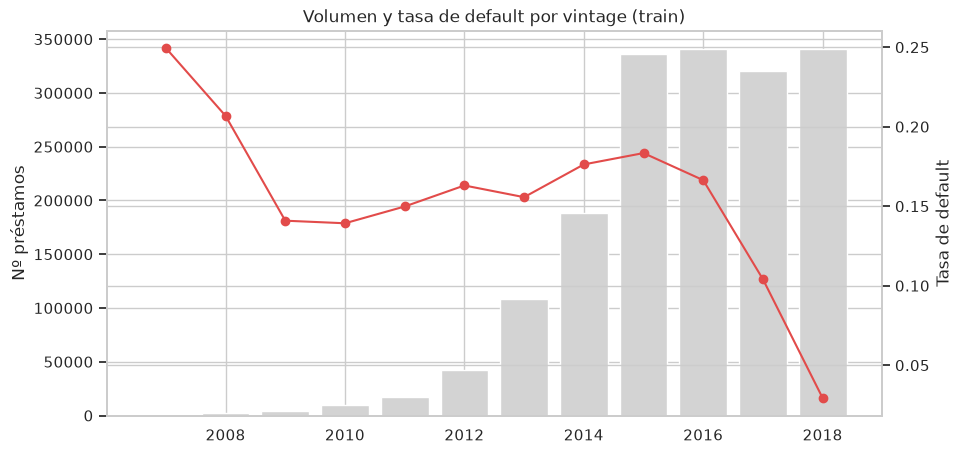

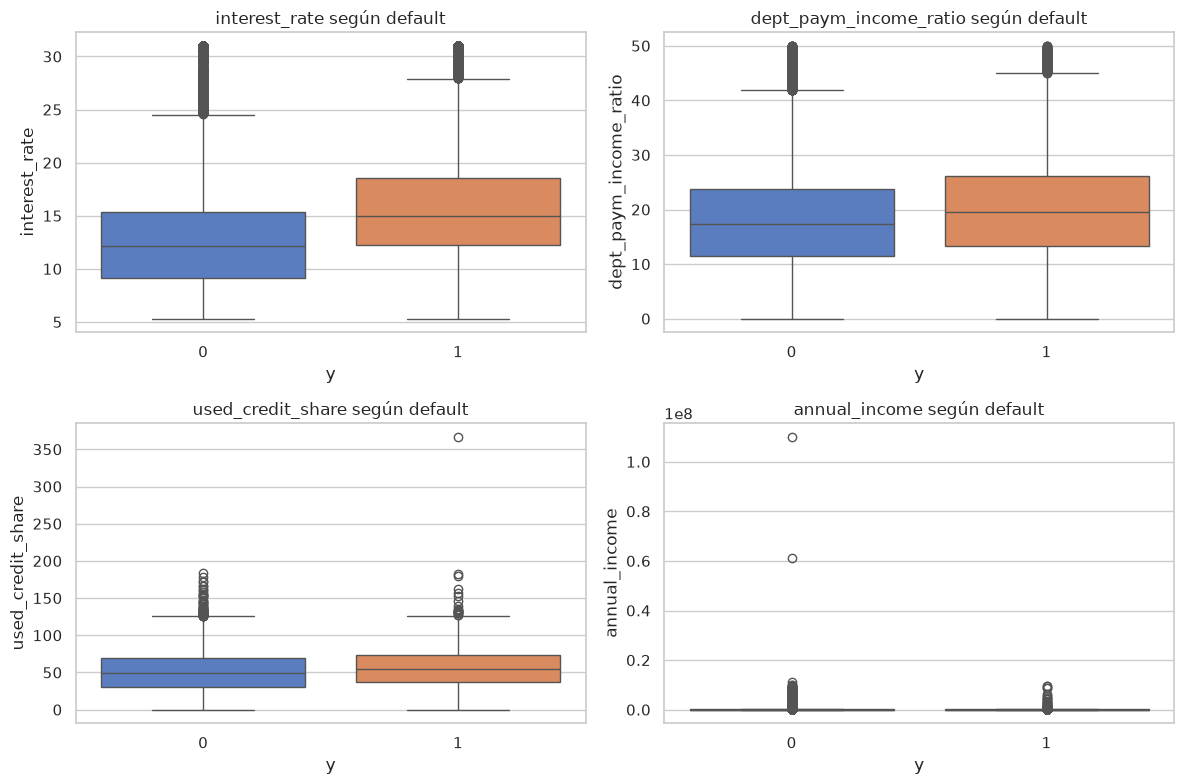

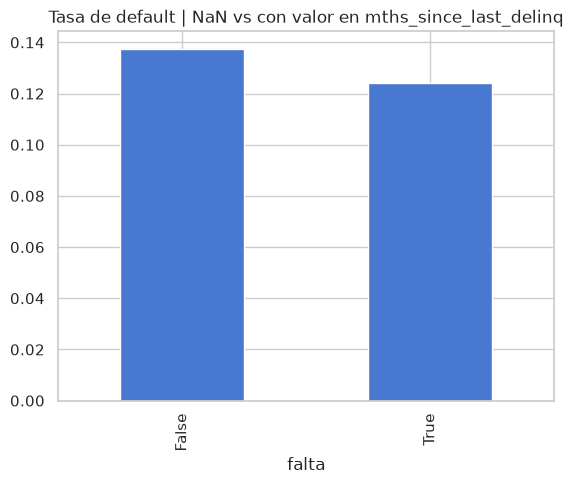

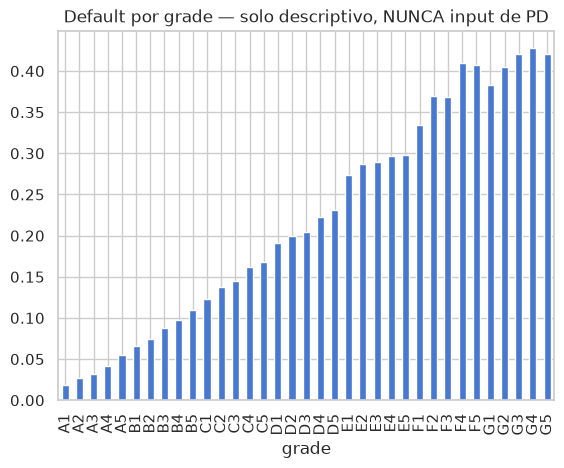

In [ ]:
# ============================================================
# 📊 PRIMERAS VISUALIZACIONES — SOLO TRAIN
# ============================================================

# --- Efecto vintage: volumen y tasa de default por año de emisión ---
# agg con nombre: n = conteo de préstamos, tasa = media de y (tasa de default)
vintage = train_df.groupby('issue_date_year').agg(
    n=(TARGET_COL, 'size'), tasa=(TARGET_COL, 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(vintage.index, vintage['n'], color='lightgray')   # volumen (eje izquierdo)
ax1.set_ylabel('Nº préstamos')
ax2 = ax1.twinx()                                          # segundo eje Y para otra escala
ax2.plot(vintage.index, vintage['tasa'], 'o-', color='#E24B4A')   # tasa de default
ax2.set_ylabel('Tasa de default')
plt.title('Volumen y tasa de default por vintage (train)')
plt.show()

# --- Señal predictiva inicial: numéricas clave según default ---
# Rejilla 2x2; zip + ravel empareja cada eje con una columna sin usar índices
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(),
                   ['interest_rate', 'dept_paym_income_ratio', 'used_credit_share', 'annual_income']):
    sns.boxplot(x=train_df[TARGET_COL], y=train_df[col], ax=ax, palette='muted')
    ax.set_title(f'{col} según default')   # si las cajas se separan, hay señal predictiva
plt.tight_layout()
plt.show()

# --- El nulo como señal: default con/sin valor en mths_since_last_delinq ---
# assign crea al vuelo la columna 'falta' sin modificar el DataFrame
col = 'mths_since_last_delinq'
(train_df.assign(falta=train_df[col].isna())
          .groupby('falta')[TARGET_COL].mean()   # tasa de default de cada grupo
          .plot(kind='bar', title=f'Tasa de default | NaN vs con valor en {col}'))
plt.show()

# --- Grade: SOLO descriptivo (prohibido como input de PD) ---
# observed=True: necesario al ser dtype category (evita mostrar categorías vacías)
(train_df.groupby('grade', observed=True)[TARGET_COL].mean()
          .plot(kind='bar', title='Default por grade — solo descriptivo, NUNCA input de PD'))
plt.show()

## **🔧 Semana 2 · Saneamiento de la cartera y exploración de señales**

### **2.1 🔍 Detección de outliers: doble criterio estadístico**

Antes de modelizar necesitamos saber qué variables tienen colas extremas que puedan
distorsionar al modelo. Para cada variable numérica de originación aplicamos **dos
criterios combinados**:

1. **Regla de Tukey**: cuántos datos caen por encima del techo `Q3 + 1.5·IQR`. Si es
   más del 1% de la muestra, no es ruido marginal: es una cola estructural.
2. **Ratio Max/Q3 (el "factor sorpresa")**: si el máximo es más de 10 veces el tercer
   cuartil, sospechamos de error de captura o de un extremo que ningún modelo debe ver.

Solo marcamos para capping las variables que cumplen **ambas condiciones**. Por eso
`funded_amnt` (máx 40k, ratio 2x) se mantiene tal cual: su tope es contractual, no un
error. Y por eso `annual_income` (ratio 1.158x) o `num_30+_delinq_in_2yrs` (18,8% por
encima del techo) sí requieren intervención. El resultado: 14 variables marcadas.

In [ ]:
# ============================================================
# 🔍 DETECCIÓN Y ESTRATEGIA DE OUTLIERS
# Objetivo: Identificar variables que requieren Winsorization/Capping
# Criterio: Combinación de Regla de Tukey + Magnitud Relativa (Ratio)
# ============================================================

def evaluar_riesgo_outlier(s, nombre):
    """
    Evalúa si una variable numérica requiere tratamiento de outliers.
    
    Retorna:
        bool: True si se recomienda CAPPING/WINSORIZACIÓN.
              False si la distribución es aceptable tal cual.
    """
    # Limpieza previa: quitar NaNs para calcular cuartiles estables
    s_clean = s.dropna()
    if len(s_clean) == 0: # Si solo hay NaNs, no se requiere tratamiento
        return False
        
    q1, q3 = s_clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    
    # --- Métrica 1: La regla clásica de Tukey ---
    techo_iqr = q3 + 1.5 * iqr
    suelo_iqr = q1 - 1.5 * iqr
    
    n_fuera_arriba = (s_clean > techo_iqr).sum() # Cuantos préstamos tienen valores extremadamente altos 
    pct_fuera_arriba = n_fuera_arriba / len(s_clean) # Porcentaje de préstamos con valores extremadamente altos
    
    # --- Métrica 2: La magnitud relativa (el "factor sorpresa") ---
    # Si el máximo es >10x el P75, sospechamos de error o cola extrema peligrosa
    ratio_max_q3 = s_clean.max() / q3 if q3 != 0 else np.inf # Si Q3= 0 no se puede dividir y else np.inf asume infinitud (requiere revisión manual o cap).
    
    # --- Veredicto Automático ---
    # Cap necesario SI:
    # 1. Hay más del 1% de datos fuera del techo IQR (no es ruido marginal)
    # AND
    # 2. El máximo es desproporcionado (>10x Q3) O el mínimo es negativo imposible (<0)
    
    flag_cap = (pct_fuera_arriba > 0.01) and (ratio_max_q3 > 10)
    
    # Diagnóstico visual para el log del notebook
    print(f"📊 {nombre}:")
    print(f"   ├─ Q1={q1:.2f} | Mediana={s_clean.median():.2f} | Q3={q3:.2f}")
    print(f"   ├─ Techo Tukey={techo_iqr:.2f} | Máximo Real={s_clean.max():.2f}")
    print(f"   ├─ % Fuera Arriba={pct_fuera_arriba:.2%} | Ratio Max/Q3={ratio_max_q3:.1f}x")
    print(f"   └─ VEREDICTO: {'🔴 REQUIERE CAPPING' if flag_cap else '🟢 MANTENER TAL CUAL'}\n")
    
    return flag_cap

# --- Aplicar a todas las variables numéricas de ORIGINACIÓN ---
# Recordatorio: Las de desempeño NO se tocan aquí aún (son targets LGD/EAD)
cols_num_orig = train_df[ORIGINATION_COLS].select_dtypes(include=[np.number]).columns

variables_a_capear = []
print("="*60)
print("🚀 INICIO ANÁLISIS DE OUTLIERS EN VARIABLES DE ORIGINACIÓN")
print("="*60)

for col in cols_num_orig:
    needs_cap = evaluar_riesgo_outlier(train_df[col], col)
    if needs_cap:
        variables_a_capear.append(col)

print("-"*60)
print(f"✅ Resumen: {len(variables_a_capear)} variables identificadas para capping:")
print(variables_a_capear)
print("-"*60)

🚀 INICIO ANÁLISIS DE OUTLIERS EN VARIABLES DE ORIGINACIÓN
📊 funded_amnt:
   ├─ Q1=8000.00 | Mediana=12250.00 | Q3=20000.00
   ├─ Techo Tukey=38000.00 | Máximo Real=40000.00
   ├─ % Fuera Arriba=1.27% | Ratio Max/Q3=2.0x
   └─ VEREDICTO: 🟢 MANTENER TAL CUAL

📊 interest_rate:
   ├─ Q1=9.49 | Mediana=12.62 | Q3=15.88
   ├─ Techo Tukey=25.47 | Máximo Real=30.99
   ├─ % Fuera Arriba=1.88% | Ratio Max/Q3=2.0x
   └─ VEREDICTO: 🟢 MANTENER TAL CUAL

📊 monthly_payment:
   ├─ Q1=249.19 | Mediana=373.22 | Q3=581.58
   ├─ Techo Tukey=1080.17 | Máximo Real=1719.83
   ├─ % Fuera Arriba=3.25% | Ratio Max/Q3=3.0x
   └─ VEREDICTO: 🟢 MANTENER TAL CUAL

📊 loan_term_months:
   ├─ Q1=36.00 | Mediana=36.00 | Q3=60.00
   ├─ Techo Tukey=96.00 | Máximo Real=60.00
   ├─ % Fuera Arriba=0.00% | Ratio Max/Q3=1.0x
   └─ VEREDICTO: 🟢 MANTENER TAL CUAL

📊 issue_date_year:
   ├─ Q1=2015.00 | Mediana=2016.00 | Q3=2017.00
   ├─ Techo Tukey=2020.00 | Máximo Real=2018.00
   ├─ % Fuera Arriba=0.00% | Ratio Max/Q3=1.0x
   └─

### **2.2 ✂️Winsorización: capar sin tirar filas**

Con la lista de variables marcadas, aplicamos **Winsorización al percentil 99.5**:
todo valor por encima de ese umbral se sustituye por el umbral. No eliminamos filas
(prohibido por las reglas del reto): solo comprimimos la cola extrema.

El detalle crítico de ingeniería: los umbrales se **aprenden en train** y se guardan
en el diccionario `CAP_LIMITS`. Cuando llegue el momento de puntuar test, usaremos
exactamente esos mismos techos, no los recalcularemos allí. Recalcular en test sería
una fuga de información: estaríamos usando la distribución del futuro para limpiar el
futuro.

In [ ]:
# --- APLICAR WINSORIZATION A LAS VARIABLES MARCADAS ---
LIMIT_PERCENTILE = 0.995  # Conservador: cortamos por el top 0.5%

for col in variables_a_capear:
    limite_superior = train_df[col].quantile(LIMIT_PERCENTILE)
    
    # Aplicamos el cap SOLO si supera el límite (no tocamos los normales)
    train_df[col] = train_df[col].clip(upper=limite_superior)
    
    print(f"✂️  Variable '{col}' capped en {limite_superior:.2f}")

# IMPORTANTE: Guardar estos límites ya capeados para aplicarlos EXACTOS a test_df después
CAP_LIMITS = {col: train_df[col].max() for col in variables_a_capear} 
print("\n💾 Límites de capping guardados para aplicación en Test:", CAP_LIMITS)

✂️  Variable 'annual_income' capped en 350000.00
✂️  Variable 'num_30+_delinq_in_2yrs' capped en 5.00
✂️  Variable 'num_derogatory_pub_rec' capped en 3.00
✂️  Variable 'num_inq' capped en 8.00
✂️  Variable 'num_inq_in_6mths' capped en 4.00
✂️  Variable 'num_inq_in_12mths' capped en 11.00
✂️  Variable 'total_credit_revolving_bal' capped en 137149.61
✂️  Variable 'max_bal_owed' capped en 29101.00
✂️  Variable 'num_open_trades_in_6mths' capped en 5.00
✂️  Variable 'num_installment_acc_op_in_12mths' capped en 4.00
✂️  Variable 'num_installment_acc_op_in_24mths' capped en 8.00
✂️  Variable 'mths_since_last_installment_acc_op' capped en 153.00
✂️  Variable 'num_rev_trades_op_in_12mths' capped en 8.00
✂️  Variable 'num_rev_trades_op_in_24mths' capped en 14.00

💾 Límites de capping guardados para aplicación en Test: {'annual_income': np.float32(350000.0), 'num_30+_delinq_in_2yrs': np.int64(5), 'num_derogatory_pub_rec': np.int64(3), 'num_inq': np.float32(8.0), 'num_inq_in_6mths': np.int64(4), '

### **2.3 🚨Valores centinela y caps de negocio**

Hay valores que no son outliers estadísticos sino **errores o códigos**: el `-1` en
`dept_paym_income_ratio` es imposible (un ratio de deuda no puede ser negativo) y
funciona como centinela de "dato no disponible". Lo tratamos en dos pasos: creamos un
indicador binario `dti_sentinel` (el propio centinela es información) y sustituimos el
`-1` por `NaN`, que luego recibirá el tratamiento de nulos de la celda 2.4.

Aprovechamos para aplicar un **cap de negocio** a `used_credit_share`: una utilización
por encima del 100% (extralímite) es real pero extrema; la capamos a 100 y documentamos
la decisión para la Comunidad. Todas las reglas quedan registradas en `REGLAS_NEGOCIO`
para replicarlas idénticas en test.

In [ ]:
# ============================================================
# 🚨 VALORES CENTINELA Y CAPS DE NEGOCIO
# Objetivo: tratar valores "imposibles" que no son outliers estadísticos
# Regla: toda transformación aprendida en train se registra para test
# ============================================================

# --- El centinela -1 en dept_paym_income_ratio ---
# Contamos cuántos -1 hay en train ANTES de tocar nada (diagnóstico)
n_sentinel = (train_df['dept_paym_income_ratio'] == -1).sum()
print(f"Centinelas -1 en DTI (train): {n_sentinel:,}")   # informe de cuántos hay

# Creamos un indicador binario (dummy): "este registro traía el centinela -1"
# (True si el valor es -1, False si no lo es). .astype(np.int8): Convierte esos True/False en 1/0.
# (el modelo podrá usar esa ausencia como señal, no la desperdiciamos)
train_df['dti_sentinel'] = (train_df['dept_paym_income_ratio'] == -1).astype(np.int8)

# Sustituimos -1 por NaN: un ratio negativo no es un valor, es una ausencia de valor
train_df['dept_paym_income_ratio'] = train_df['dept_paym_income_ratio'].replace(-1, np.nan)

# --- Cap de negocio en used_credit_share ---
# Contamos cuántos registros superan el 100% de utilización (extralímite)
n_over = (train_df['used_credit_share'] > 100).sum()
print(f"Utilización > 100% en train: {n_over:,}")   # diagnóstico previo al cap

# Capamos al 100: por negocio, "más que totalmente utilizado" no añade información
train_df['used_credit_share'] = train_df['used_credit_share'].clip(upper=100)

# --- Registro de reglas para test ---
# Diccionario con las decisiones de negocio: se aplicarán idénticas al puntuar test
REGLAS_NEGOCIO = {
    'dti_sentinel_valor': -1,      # valor que consideramos centinela en el DTI
    'used_credit_share_cap': 100,  # techo de negocio para la utilización revolving
}
print("🚨 Reglas de negocio guardadas:", REGLAS_NEGOCIO)   # confirmación visual

Centinelas -1 en DTI (train): 0
Utilización > 100% en train: 5,624
🚨 Reglas de negocio guardadas: {'dti_sentinel_valor': -1, 'used_credit_share_cap': 100}


### **2.4 🕳️Nulos como señal e imputación controlada**

En la Semana 1 descubrimos que aquí los nulos tienen dos almas: en las columnas
`mths_since_*` significan *"el evento nunca ocurrió"* (un perfil bueno), y en el bloque
de buró (~40% de nulos) significan *"sin ficha disponible"*. En ambos casos el nulo
**es información**, así que la estrategia tiene dos patas:

1. **Indicadores binarios** `falta_<columna>`: el modelo sabrá distinguir "nunca tuvo
   morosidad" de "morosidad hace 30 meses".
2. **Imputación diferenciada**: las `mths_since_*` se rellenan con un valor alto
   (P99 de train, coherente con "hace mucho / nunca"); el resto con la **mediana** de
   train, robusta frente a extremos ya capeados.

Cada valor de imputación se guarda en el diccionario `IMPUTACIONES`: test recibirá
exactamente los mismos números, nunca los suyos propios.

In [ ]:
# ============================================================
# 🕳️ NULOS COMO SEÑAL + IMPUTACIÓN CONTROLADA
# Objetivo: (a) guardar el "falta dato" como feature, (b) rellenar con valores de train
# Regla: todo valor aprendido aquí viaja en un diccionario hasta test
# ============================================================

# --- Detección automática de columnas con nulos ---
# Nos quedamos con las columnas numéricas (las de texto se trataron en 2.5)
cols_numericas = train_df.select_dtypes(include=[np.number]).columns
# Lista de columnas numéricas que aún tienen algún nulo en train (.any)
COLS_CON_NULOS = [c for c in cols_numericas if train_df[c].isnull().any()]
print("Columnas con nulos a tratar:", COLS_CON_NULOS)   # diagnóstico de entrada

# --- Indicadores binarios de nulo ---
for c in COLS_CON_NULOS:                                   # recorremos cada columna con nulos
    train_df[f'falta_{c}'] = train_df[c].isnull().astype(np.int8)  # 1 = era nulo, 0 = no

# --- Imputación diferenciada aprendida en train ---
IMPUTACIONES = {}                                          # diccionario {columna: valor} para test
for c in COLS_CON_NULOS:                                   # recorremos de nuevo cada columna
    if c.startswith('mths_since'):                         # si es "meses desde un evento"...
        valor = train_df[c].quantile(0.99)                 # ...valor alto: "hace mucho / nunca"
    else:                                                  # para el resto de columnas...
        valor = train_df[c].median()                       # ...mediana: robusta frente a extremos
    IMPUTACIONES[c] = valor                                # guardamos el valor aprendido para test
    train_df[c] = train_df[c].fillna(valor)                # rellenamos los huecos en train

# --- Verificación ---
# Tras imputar no debe quedar ningún nulo en las numéricas que verá el modelo
print("Nulos restantes:", train_df[COLS_CON_NULOS].isnull().sum().sum())
# Mostramos redondeados los valores que test deberá usar (transparencia del pipeline)
print("Imputaciones guardadas:", {k: round(float(v), 2) for k, v in IMPUTACIONES.items()}) 

Columnas con nulos a tratar: ['mths_since_last_delinq', 'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths', 'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim', 'num_inq', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq', 'emp_length_num']
Nulos restantes: 0
Imputaciones guardadas: {'mths_since_last_delinq': 81.0, 'num_open_trades_in_6mths': 1.0, 'num_installment_acc_op_in_12mths': 0.0, 'num_installment_acc_op_in_24mths': 1.0, 'mths_since_last_installment_acc_op': 135.0, 'num_rev_trades_op_in_12mths': 1.0, 'num_rev_trades_op_in_24mths': 2.0, 'max_bal_owed': 4403.0, 'bal_to_cred_lim': 58.0, 'num_inq': 0.0, 'mths_since_recent_bankcard_delinq': 84.0, 'mths_since_recent_revol_delinq': 82.0, 'emp_length_num': 6.0}


### **2.5 🔁Redundancias y la variable de texto**

Con los datos ya saneados, buscamos **columnas que cuenten dos veces la misma historia**:
dos medidores de utilización revolving, ventanas anidadas de consultas de crédito y el
par `addr_state` / `region_code` (el segundo es una agregación del primero). Lo medimos
con correlación de Pearson y decidimos con un criterio mixto estadístico + de negocio:
fuera `region_code`, `bal_to_cred_lim` y `num_inq` (redundantes y, las dos últimas, con
un 40% de nulos que sus alternativas no tienen).

`emp_title` merece párrafo aparte: texto libre con decenas de miles de categorías y un
7% de nulos. Por ahora extraemos lo único que es estable y barato —el indicador binario
"declaró profesión"— y apartamos el texto; en la Semana 3 valoraremos un target-encoding
de los títulos frecuentes si aporta señal. Cerrar la celda **refrescando `PD_FEATURES`**
(originales válidas − descartes + ingeniería) deja el contrato de features del modelo de
PD escrito en un solo sitio.

In [ ]:
# ============================================================
# 🔁 REDUNDANCIAS Y VARIABLES DE TEXTO
# Objetivo: eliminar columnas duplicadas y decidir qué hacer con emp_title
# Regla: eliminar COLUMNAS es selección de features (permitido); eliminar filas, no
# ============================================================

# --- Correlación de pares sospechosos ---
pares_sospechosos = [                                        # pares que intuimos redundantes
    ('used_credit_share', 'bal_to_cred_lim'),                # dos medidores de utilización
    ('num_inq', 'num_inq_in_12mths'),                        # consultas totales vs ventana 12m
    ('num_inq_in_6mths', 'num_inq_in_12mths'),               # ventanas anidadas 6m y 12m
    ('mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq'),  # morosidad bankcard vs revolving
]
for a, b in pares_sospechosos:                               # recorremos cada par
    corr = train_df[[a, b]].corr().iloc[0, 1]                # correlación de Pearson del par
    print(f"corr({a}, {b}) = {corr:.3f}")                    # la mostramos para decidir con datos

# --- Columnas que descartamos (decisión documentada) ---
DROP_COLS = ['region_code',       # agregación de addr_state: misma info, menos detalle
             'bal_to_cred_lim',   # redundante con used_credit_share y con 40% de nulos
             'num_inq']            # redundante con las ventanas 6m/12m y con 40% de nulos

# --- emp_title: texto libre de alta cardinalidad ---
print(f"Cardinalidad emp_title: {train_df['emp_title'].nunique():,}")   # cuántos títulos distintos
print(f"Nulos emp_title: {train_df['emp_title'].isnull().mean():.2%}")   # cuánto falta
display(train_df['emp_title'].value_counts().head(10))                  # top 10 para intuición
train_df['emp_title_known'] = train_df['emp_title'].notnull().astype(np.int8)  # indicador "declaró profesión" 
# notnull() detecta si es texto o NaN y .astype(np.int8) convierte True/False en 1/0. 
DROP_COLS += ['emp_title',      # el texto crudo se aparta hasta la Semana 3
              'emp_length']     # su versión numérica (emp_length_num) ya lo sustituye

# --- Aplicar el dropping en train ---
train_df = train_df.drop(columns=DROP_COLS)                  # eliminamos las columnas de train
print(f"Columnas eliminadas: {DROP_COLS}")                   # registro de qué se fue
print(f"Ancho de train tras dropping: {train_df.shape[1]}")  # comprobación del nuevo ancho

# --- Refresh del contrato de features de PD ---
INGENIERIA_COLS = ['emp_length_num', 'dti_sentinel', 'emp_title_known'] + \
                  [f'falta_{c}' for c in COLS_CON_NULOS]      # columnas nuevas creadas en Semana 2
PD_FEATURES = [c for c in ORIGINATION_COLS if c not in DROP_COLS] + INGENIERIA_COLS  # originales válidas + ingeniería
print(f"Features PD tras Semana 2: {len(PD_FEATURES)}")      # tamaño final del contrato de features

corr(used_credit_share, bal_to_cred_lim) = 0.519
corr(num_inq, num_inq_in_12mths) = 0.576
corr(num_inq_in_6mths, num_inq_in_12mths) = 0.503
corr(mths_since_recent_bankcard_delinq, mths_since_recent_revol_delinq) = 0.772
Cardinalidad emp_title: 419,267
Nulos emp_title: 6.94%


emp_title
Teacher             27899
Manager             26092
Owner               16712
Registered Nurse    11998
RN                  11208
Driver              11037
Supervisor          10862
Sales                9907
Project Manager      8359
Office Manager       7234
Name: count, dtype: int64

Columnas eliminadas: ['region_code', 'bal_to_cred_lim', 'num_inq', 'emp_title', 'emp_length']
Ancho de train tras dropping: 57
Features PD tras Semana 2: 50


### **2.6 🎯 Señales de default: ¿qué separa a los que impagan?**

Primer EDA "serio" sobre los datos ya saneados, y siempre sobre train. Miramos dos
familias de señales:

1. **Numéricas**: correlación point-biserial de cada feature con `y`. Es la forma rápida
   de rankear candidatas; ojo, solo captura relación lineal/monótona (los árboles
   encontrarán después interacciones que aquí no vemos).
2. **Categóricas**: tasa de default por nivel de vivienda, verificación de ingresos,
   canal de listado y método de desembolso. Si las tasas difieren mucho entre niveles,
   la variable tiene recorrido como predictor.

Este ranking no decide aún qué entra al modelo: decide **dónde poner el ojo** en la
Semana 3 y qué gráficos llevar a la llamada grupal.

,corr_con_y
interest_rate,0.211
issue_date_year,-0.126
falta_num_installment_acc_op_in_12mths,0.106
falta_num_open_trades_in_6mths,0.106
falta_num_installment_acc_op_in_24mths,0.106
falta_num_inq,0.106
falta_max_bal_owed,0.106
falta_num_rev_trades_op_in_24mths,0.106
falta_num_rev_trades_op_in_12mths,0.106
falta_bal_to_cred_lim,0.106


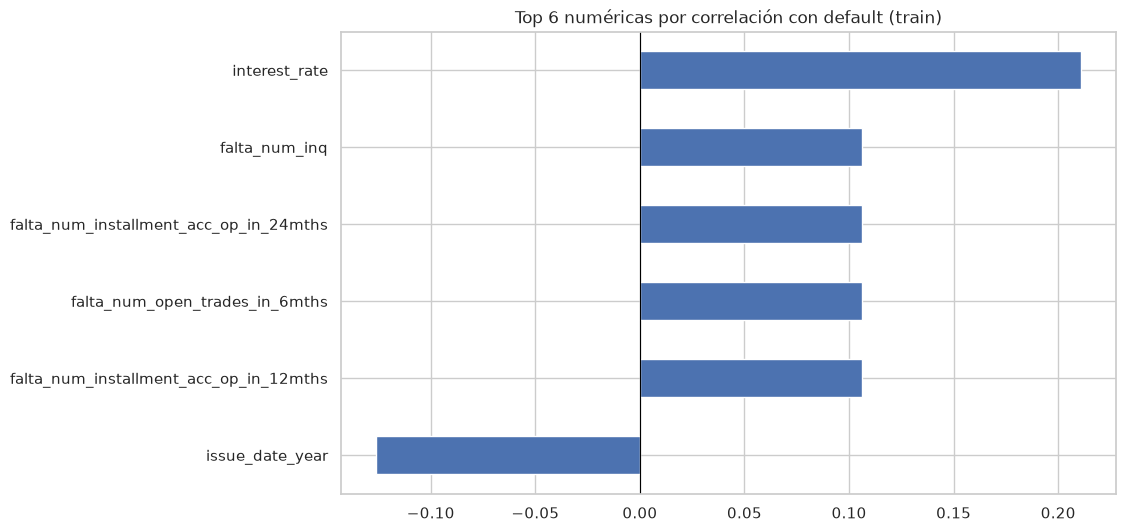


--- % default por home_ownership_status ---


,% default
home_ownership_status,
OTHER,9.280
MORTGAGE,11.490
OWN,12.930
RENT,15.010



--- % default por verification_status ---


,% default
verification_status,
Not Verified,8.970
Source Verified,13.470
Verified,17.380



--- % default por initial_list_status ---


,% default
initial_list_status,
w,11.610
f,16.030



--- % default por disbursement_method ---


,% default
disbursement_method,
DirectPay,2.390
Cash,13.450


loan_term_months
36   0.111
60   0.182
Name: y, dtype: float64


In [ ]:
# ============================================================
# 🎯 SEÑALES DE DEFAULT (EDA para PD)
# Objetivo: rankear variables por su relación con el impago
# Todo se calcula sobre train: test sigue en la caja fuerte
# ============================================================

# --- Correlación numérica con el target ---
# Filtramos solo features numéricas 
feat_num = [c for c in PD_FEATURES if pd.api.types.is_numeric_dtype(train_df[c])]
# Correlación de cada feature con y (point-biserial para target binario)
corr_y = train_df[feat_num + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL) #.drop(TARGET_COL) Elimina la fila donde y se correlaciona consigo mismo (siempre da 1.0). Es ruido.
# Reordenamos por valor absoluto: primero las señales más fuertes, sea su signo + o -
corr_y = corr_y.reindex(corr_y.abs().sort_values(ascending=False).index)
display(corr_y.head(15).to_frame('corr_con_y'))   # top 15 en tabla legible

# --- Gráfico del top 6 ---
fig, ax = plt.subplots(figsize=(10, 6))                       # lienzo horizontal para etiquetas largas
corr_y.head(6).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')  # barras horizontales del top 6
ax.set_title('Top 6 numéricas por correlación con default (train)')     # título autoexplicativo
ax.axvline(0, color='black', lw=0.8)                          # línea de referencia en cero
plt.show()                                                    # renderizamos el gráfico

# --- Tasa de default por categóricas clave ---
for col in ['home_ownership_status', 'verification_status',   # recorremos las categóricas de negocio
            'initial_list_status', 'disbursement_method']:
    tasa = train_df.groupby(col, observed=True)[TARGET_COL].mean().sort_values()  # tasa por nivel
    print(f"\n--- % default por {col} ---")                   # separador legible por variable
    display((tasa * 100).round(2).to_frame('% default'))      # tabla en porcentaje con 2 decimales

# --- Control de coherencia: plazo y vintage ---
print(train_df.groupby('loan_term_months')[TARGET_COL].mean().round(4))  # el plazo 60m debe ser más riesgoso

### **2.7 💸 Primer vistazo a la pérdida: el territorio de LGD y EAD**

Aquí sí podemos (y debemos) usar las variables de desempeño: son la materia prima de la
pérdida observada, aunque sigan prohibidas para el modelo de PD. Tres preguntas guían
esta celda:

1. **¿En qué se parecen los flujos de cobro de quien impaga frente a quien no?**
   Comparativa de medias de las cinco variables de desempeño por estado de default.
2. **¿Cuánto se recupera cuando hay impago?** Definimos una recuperación proxy
   (`princ_rec / funded_amnt`, acotada a [0, 1]) y miramos su distribución solo entre
   defaults: ahí vive la futura LGD observada.
3. **¿Cuánto queda pendiente cuando llega el impago?** El principal remanente entre
   defaults es el embrión del futuro EAD observado.

Esto es exploración: las definiciones formales de los targets LGD y EAD llegan en la
Semana 3, pero saldrán de exactamente estos gráficos.

,no_default,default
princ_rec,10216.610,4498.220
interest_rec,2347.440,2731.320
late_fees_rec,0.870,5.250
paym_rec_for_tot_amnt_fund,12564.920,8313.050
remaining_princ_for_tot_amnt_fund,4456.620,880.750


Recuperación media en defaults: 31.02%
Recuperación mediana en defaults: 26.07%


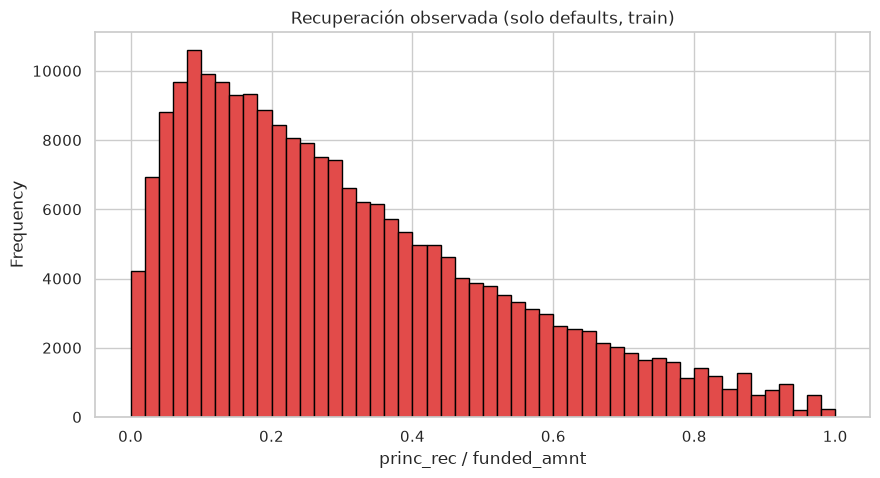

EAD medio en defaults: 881 $
EAD mediano en defaults: 0 $


In [ ]:
# ============================================================
# 💸 PRIMER VISTAZO A LA PÉRDIDA (EDA para LGD/EAD)
# Objetivo: entender los flujos de cobro y la pérdida observada en train
# Aquí SÍ usamos variables de desempeño: son la base de LGD/EAD (no de PD)
# ============================================================

# --- Perfil de desempeño según default ---
# Medias de las 5 variables de desempeño separadas por y=0 / y=1
perf_por_y = train_df.groupby(TARGET_COL)[PERFORMANCE_COLS].mean().T  # transponemos para leer por variable
perf_por_y.columns = ['no_default', 'default']                        # renombramos columnas para claridad
display(perf_por_y.round(2))                                          # tabla comparativa redondeada

# --- Recuperación observada en defaults ---
# Proxy de recuperación: principal cobrado / importe financiado, acotado entre 0 y 1
train_df['recovery_rate'] = (train_df['princ_rec'] / train_df['funded_amnt']).clip(0, 1)
rec_defaults = train_df.loc[train_df[TARGET_COL] == 1, 'recovery_rate']  # solo los que impagaron
print(f"Recuperación media en defaults: {rec_defaults.mean():.2%}")      # cuánto vuelve, en media
print(f"Recuperación mediana en defaults: {rec_defaults.median():.2%}")  # cuánto vuelve, caso típico

# --- Distribución de la recuperación ---
fig, ax = plt.subplots(figsize=(10, 5))                                  # lienzo del histograma
rec_defaults.plot(kind='hist', bins=50, ax=ax, color='#E24B4A', edgecolor='black')  # 50 cubos con borde
ax.set_title('Recuperación observada (solo defaults, train)')            # título autoexplicativo
ax.set_xlabel('princ_rec / funded_amnt')                                 # etiqueta del eje X
plt.show()                                                               # renderizamos

# --- Principal pendiente (embrión del EAD) ---
ead_defaults = train_df.loc[train_df[TARGET_COL] == 1, 'remaining_princ_for_tot_amnt_fund']  # pendiente en defaults
print(f"EAD medio en defaults: {ead_defaults.mean():,.0f} $")            # exposición típica al impagar
print(f"EAD mediano en defaults: {ead_defaults.median():,.0f} $")        # exposición del caso central 